# NIFTY 50 Next-Day Direction Prediction

Trying to predict whether NIFTY 50 goes up or down the next day. Steps: look at the data first,
build some features from it, train a few models and test them properly (no cheating with future
data), then check if the whole thing actually makes money once you account for trading costs.

Why direction and not the actual price? Because guessing the exact next price of an index is
basically impossible — it's too liquid and too watched by too many people for that to work.
What you *can* realistically go for is just a decent guess on direction, with some confidence
attached to it. That's closer to how real trading desks think about it anyway - they don't
predict prices, they size bets based on probability.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
sns.set_style("whitegrid")

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(name):
    """Save the current figure to figures/<name>.png at print quality, then continue to plt.show()."""
    plt.savefig(os.path.join(FIG_DIR, f"{name}.png"), dpi=150, bbox_inches="tight")

def _flatten(d):
    if isinstance(d.columns, pd.MultiIndex):
        d.columns = d.columns.get_level_values(0)
    return d

# 10+ years of NIFTY 50 index data
df = yf.download("^NSEI", start="2015-01-01", end="2025-12-31", auto_adjust=True)
df = _flatten(df)[["Open", "High", "Low", "Close", "Volume"]].dropna()

# Cross-asset context: the US market closes a few hours before NIFTY opens the next day,
# so what S&P 500 did overnight can actually tell us something useful (not just circular
# info derived from NIFTY's own price history). Also grabbing India VIX and USD/INR since
# both matter for risk sentiment and flows.
spx = _flatten(yf.download("^GSPC", start="2015-01-01", end="2025-12-31", auto_adjust=True))["Close"]
vix_in = _flatten(yf.download("^INDIAVIX", start="2015-01-01", end="2025-12-31", auto_adjust=True))["Close"]
usdinr = _flatten(yf.download("INR=X", start="2015-01-01", end="2025-12-31", auto_adjust=True))["Close"]

exog = pd.DataFrame(index=df.index)
exog["spx_prev_ret"] = spx.pct_change().reindex(df.index).ffill()   # prior US session return
exog["india_vix"] = vix_in.reindex(df.index).ffill()
exog["usdinr_ret"] = usdinr.pct_change().reindex(df.index).ffill()
exog = exog.fillna(method="ffill").fillna(0)

print("Shape:", df.shape)
print("Date range:", df.index.min().date(), "to", df.index.max().date())
df.head()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/tmp/ipykernel_3506/2738005808.py:37: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  exog = exog.fillna(method="ffill").fillna(0)


Shape: (2707, 5)
Date range: 2015-01-02 to 2025-12-30


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-02,8288.700195,8410.599609,8288.700195,8395.450195,101900
2015-01-05,8407.950195,8445.599609,8363.900391,8378.400391,118200
2015-01-06,8325.299805,8327.849609,8111.350098,8127.350098,172800
2015-01-07,8118.649902,8151.200195,8065.450195,8102.100098,164100
2015-01-08,8191.399902,8243.500000,8167.299805,8234.599609,143800


## 1. Exploratory Data Analysis

Just looking at the data before doing anything fancy. All the charts below also get saved as PNGs into a `figures/` folder next to this notebook, so you don't have to screenshot them later.

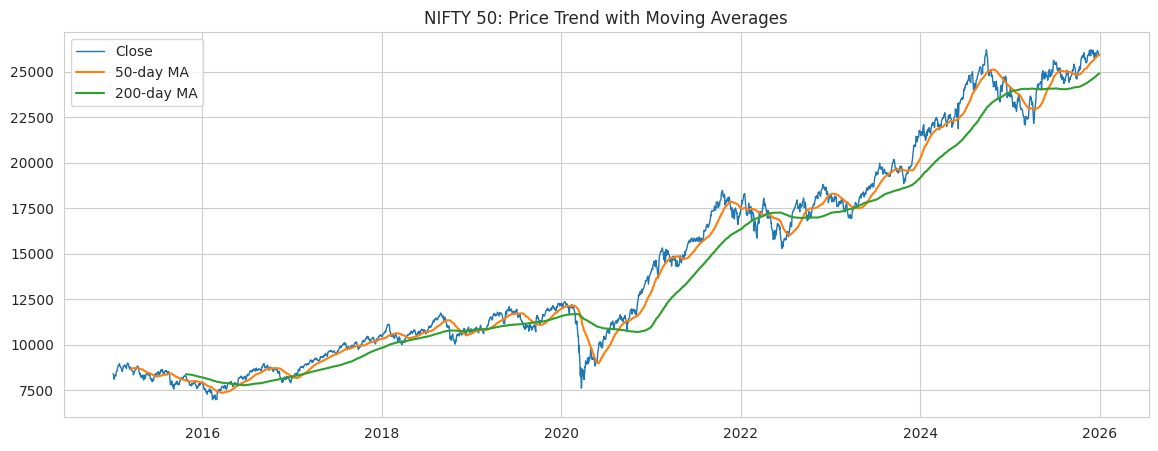

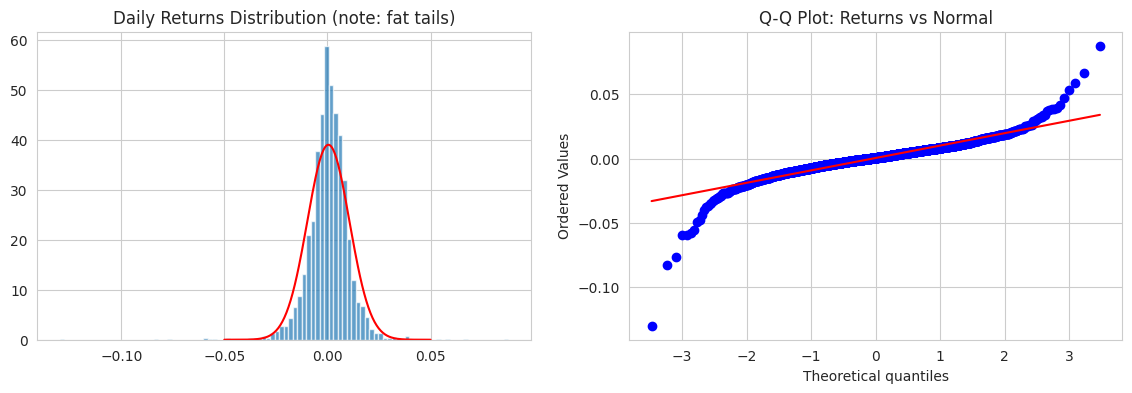

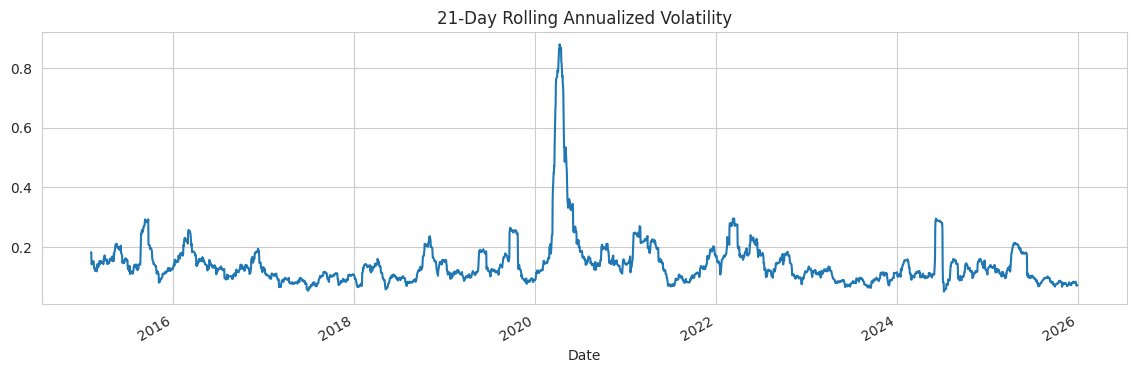

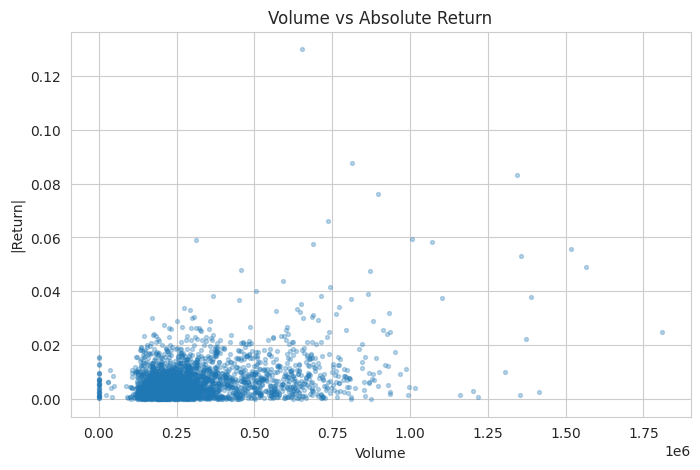

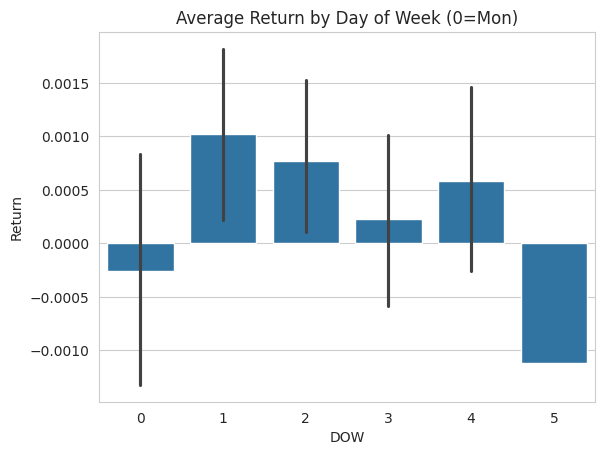

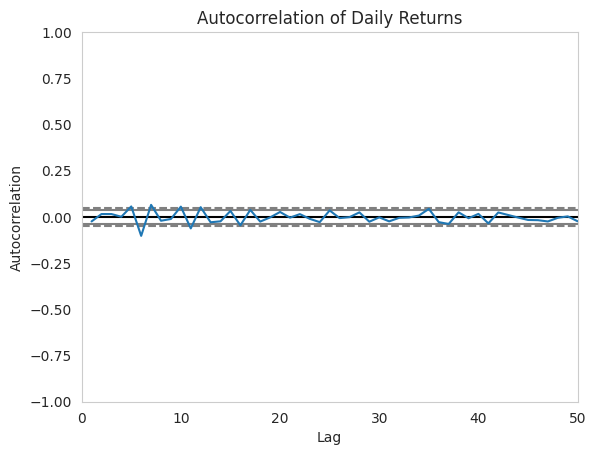

In [3]:
# 1. Price trend with moving averages
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df["Close"], label="Close", lw=1)
ax.plot(df["Close"].rolling(50).mean(), label="50-day MA")
ax.plot(df["Close"].rolling(200).mean(), label="200-day MA")
ax.set_title("NIFTY 50: Price Trend with Moving Averages")
ax.legend(); save_fig("01_price_trend"); plt.show()

# 2. Daily returns distribution vs normal curve
df["Return"] = df["Close"].pct_change()
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].hist(df["Return"].dropna(), bins=100, density=True, alpha=0.7)
ax[0].set_title("Daily Returns Distribution (note: fat tails)")
from scipy import stats
x = np.linspace(-0.05, 0.05, 200)
ax[0].plot(x, stats.norm.pdf(x, df["Return"].mean(), df["Return"].std()), 'r-')
stats.probplot(df["Return"].dropna(), dist="norm", plot=ax[1])
ax[1].set_title("Q-Q Plot: Returns vs Normal")
save_fig("02_returns_distribution"); plt.show()

# 3. Rolling volatility (annualized)
df["Volatility"] = df["Return"].rolling(21).std() * np.sqrt(252)
df["Volatility"].plot(figsize=(14, 4), title="21-Day Rolling Annualized Volatility")
save_fig("03_rolling_volatility"); plt.show()

# 4. Volume vs absolute returns relationship
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df["Volume"], df["Return"].abs(), alpha=0.3, s=8)
ax.set_xlabel("Volume"); ax.set_ylabel("|Return|")
ax.set_title("Volume vs Absolute Return")
save_fig("04_volume_vs_abs_return"); plt.show()

# 5. Day-of-week effect
df["DOW"] = df.index.dayofweek
sns.barplot(x="DOW", y="Return", data=df.reset_index(), errorbar=("ci", 95))
plt.title("Average Return by Day of Week (0=Mon)"); save_fig("05_day_of_week_effect"); plt.show()

# 6. Autocorrelation of returns (shows why naive prediction is hard)
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df["Return"].dropna())
plt.title("Autocorrelation of Daily Returns"); plt.xlim(0, 50)
save_fig("06_autocorrelation"); plt.show()

## 2. Feature Engineering

Building indicators using only data available up to that day - no peeking into the future.

In [4]:
def add_features(df):
    d = df.copy()
    eps = 1e-9  # avoid divide-by-zero on flat/illiquid stretches

    # Lagged returns
    for lag in [1, 2, 3, 5, 10]:
        d[f"ret_lag{lag}"] = d["Return"].shift(lag)

    # Rolling statistics
    for w in [5, 10, 21]:
        d[f"roll_mean{w}"] = d["Return"].rolling(w).mean()
        d[f"roll_std{w}"]  = d["Return"].rolling(w).std()

    # RSI (14)
    delta = d["Close"].diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    d["RSI"] = 100 - 100 / (1 + gain / (loss + eps))

    # MACD
    ema12 = d["Close"].ewm(span=12).mean()
    ema26 = d["Close"].ewm(span=26).mean()
    d["MACD"] = ema12 - ema26
    d["MACD_signal"] = d["MACD"].ewm(span=9).mean()

    # Bollinger position
    ma20 = d["Close"].rolling(20).mean()
    sd20 = d["Close"].rolling(20).std()
    d["BB_pos"] = (d["Close"] - ma20) / (2 * sd20 + eps)

    # Distance from moving averages
    d["dist_ma50"] = d["Close"] / d["Close"].rolling(50).mean() - 1
    d["dist_ma200"] = d["Close"] / d["Close"].rolling(200).mean() - 1

    # Volume z-score
    d["vol_z"] = (d["Volume"] - d["Volume"].rolling(21).mean()) / (d["Volume"].rolling(21).std() + eps)
    d["DOW"] = d.index.dayofweek

    # Cross-asset features (see previous cell): these carry genuine external information,
    # not just re-derived technical structure from NIFTY's own price history
    d = d.join(exog)

    # TARGET: next-day direction (1 = up, 0 = down/flat)
    d["Target"] = (d["Return"].shift(-1) > 0).astype(int)

    return d.replace([np.inf, -np.inf], np.nan).dropna()

data = add_features(df)
features = [c for c in data.columns if c not in
            ["Open", "High", "Low", "Close", "Volume", "Return", "Target", "Volatility"]]

print(f"{len(features)} features, {len(data)} usable rows")
print(f"Target balance -> Up: {data['Target'].mean():.2%}  Down/Flat: {1 - data['Target'].mean():.2%}")
data[features].describe().T.round(4)

22 features, 2508 usable rows
Target balance -> Up: 53.95%  Down/Flat: 46.05%


,count,mean,std,min,25%,50%,75%,max
DOW,2508.0,1.9984,1.4117,0.0000,1.0000,2.0000,3.0000,5.0000
ret_lag1,2508.0,0.0005,0.0102,-0.1298,-0.0042,0.0007,0.0058,0.0876
ret_lag2,2508.0,0.0005,0.0102,-0.1298,-0.0042,0.0007,0.0058,0.0876
ret_lag3,2508.0,0.0005,0.0102,-0.1298,-0.0042,0.0007,0.0058,0.0876
ret_lag5,2508.0,0.0005,0.0102,-0.1298,-0.0042,0.0007,0.0058,0.0876
ret_lag10,2508.0,0.0005,0.0102,-0.1298,-0.0042,0.0007,0.0058,0.0876
roll_mean5,2508.0,0.0005,0.0045,-0.0403,-0.0018,0.0008,0.0031,0.0207
roll_std5,2508.0,0.0081,0.0062,0.0010,0.0047,0.0067,0.0095,0.0808
roll_mean10,2508.0,0.0005,0.0032,-0.0346,-0.0012,0.0007,0.0023,0.0165
roll_std10,2508.0,0.0085,0.0056,0.0020,0.0055,0.0073,0.0097,0.0662


## 3. Comparing a Few Models

Using `TimeSeriesSplit` here instead of regular cross-validation, so each fold only ever tests on data that comes after what it trained on. Normal random-split CV would leak future info into training and make everything look better than it actually is.

In [5]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

X, y = data[features], data["Target"]
tscv = TimeSeriesSplit(n_splits=5)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                             random_state=42, eval_metric="logloss"),
}

results = {}
oof_proba = {name: np.full(len(X), np.nan) for name in models}

for name, model in models.items():
    accs, aucs = [], []
    for tr, te in tscv.split(X):
        scaler = StandardScaler().fit(X.iloc[tr])
        model.fit(scaler.transform(X.iloc[tr]), y.iloc[tr])
        proba = model.predict_proba(scaler.transform(X.iloc[te]))[:, 1]
        oof_proba[name][te] = proba
        accs.append(accuracy_score(y.iloc[te], proba > 0.5))
        aucs.append(roc_auc_score(y.iloc[te], proba))
    results[name] = {"Accuracy": np.mean(accs), "AUC": np.mean(aucs),
                      "Accuracy_std": np.std(accs), "AUC_std": np.std(aucs)}

results_df = pd.DataFrame(results).T.round(4)
print("Baseline (always predict majority class):",
      round(max(y.mean(), 1 - y.mean()), 4))
results_df

Baseline (always predict majority class): 0.5395


,Accuracy,AUC,Accuracy_std,AUC_std
Logistic Regression,0.5856,0.5995,0.0315,0.0348
Random Forest,0.5813,0.5892,0.0303,0.0396
XGBoost,0.5641,0.5848,0.0290,0.0327


Best model by walk-forward AUC: Logistic Regression

              precision    recall  f1-score   support

   Down/Flat       0.56      0.44      0.49       956
          Up       0.60      0.71      0.65      1134

    accuracy                           0.59      2090
   macro avg       0.58      0.57      0.57      2090
weighted avg       0.58      0.59      0.58      2090



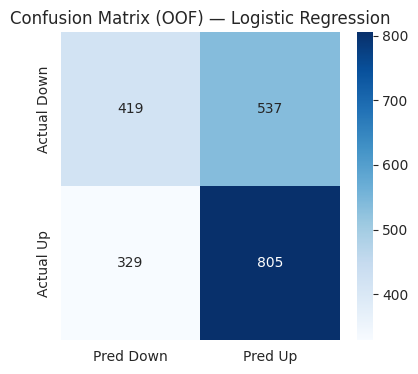

In [6]:
# Diagnostics for the best model on its out-of-fold (walk-forward) predictions
best_name = results_df["AUC"].idxmax()
mask = ~np.isnan(oof_proba[best_name])
y_true = y[mask]
y_prob = oof_proba[best_name][mask]
y_pred = (y_prob > 0.5).astype(int)

print(f"Best model by walk-forward AUC: {best_name}\n")
print(classification_report(y_true, y_pred, target_names=["Down/Flat", "Up"]))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Down", "Pred Up"], yticklabels=["Actual Down", "Actual Up"], ax=ax)
ax.set_title(f"Confusion Matrix (OOF) — {best_name}")
save_fig("07_confusion_matrix")
plt.show()

## 4. Backtest on Unseen Data

Train on the first 80% of history, then simulate trading on the last 20% which the model never saw. Also subtracting a small cost every time the position changes, since real trading isn't free.

In [7]:
# Train on first 80%, backtest on last 20%
split = int(len(data) * 0.8)
scaler = StandardScaler().fit(X.iloc[:split])
best = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                     random_state=42, eval_metric="logloss")
best.fit(scaler.transform(X.iloc[:split]), y.iloc[:split])

test = data.iloc[split:].copy()
test["proba"] = best.predict_proba(scaler.transform(X.iloc[split:]))[:, 1]
test["signal"] = (test["proba"] > 0.5).astype(int)      # long/flat strategy

COST = 0.0005  # 0.05% per trade (round-turn cost incurred on each position change)
test["next_ret"] = test["Return"].shift(-1)
trades = test["signal"].diff().abs().fillna(0)
test["strat_ret"] = test["signal"] * test["next_ret"] - trades * COST

test["strat_cum"] = (1 + test["strat_ret"].fillna(0)).cumprod()
test["bh_cum"]    = (1 + test["next_ret"].fillna(0)).cumprod()

def sharpe(r):
    r = r.dropna()
    return r.mean() / r.std() * np.sqrt(252) if r.std() > 0 else np.nan

def sortino(r):
    r = r.dropna()
    downside = r[r < 0]
    dd_std = downside.std()
    return r.mean() / dd_std * np.sqrt(252) if dd_std and dd_std > 0 else np.nan

def max_dd(cum):
    return ((cum - cum.cummax()) / cum.cummax()).min()

def calmar(r, cum):
    ann_ret = (1 + r.dropna()).prod() ** (252 / len(r.dropna())) - 1
    dd = abs(max_dd(cum))
    return ann_ret / dd if dd > 0 else np.nan

def win_rate(r):
    traded = r[r != 0].dropna()
    return (traded > 0).mean() if len(traded) else np.nan

metrics = pd.DataFrame({
    "Strategy": [
        sharpe(test["strat_ret"]), sortino(test["strat_ret"]),
        max_dd(test["strat_cum"]), calmar(test["strat_ret"], test["strat_cum"]),
        win_rate(test["strat_ret"]), trades.sum()
    ],
    "Buy & Hold": [
        sharpe(test["next_ret"]), sortino(test["next_ret"]),
        max_dd(test["bh_cum"]), calmar(test["next_ret"], test["bh_cum"]),
        np.nan, np.nan
    ]
}, index=["Sharpe", "Sortino", "Max Drawdown", "Calmar", "Win Rate", "# Trades"])

metrics.round(4)

,Strategy,Buy & Hold
Sharpe,1.0705,0.8022
Sortino,1.3131,1.0729
Max Drawdown,-0.0907,-0.1577
Calmar,1.2154,0.6356
Win Rate,0.4208,NaN
# Trades,210.0000,NaN


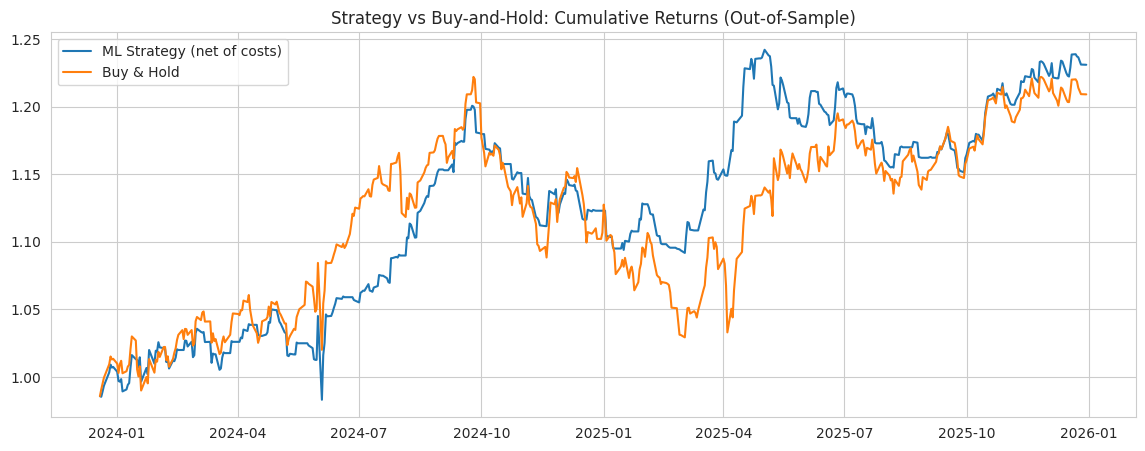

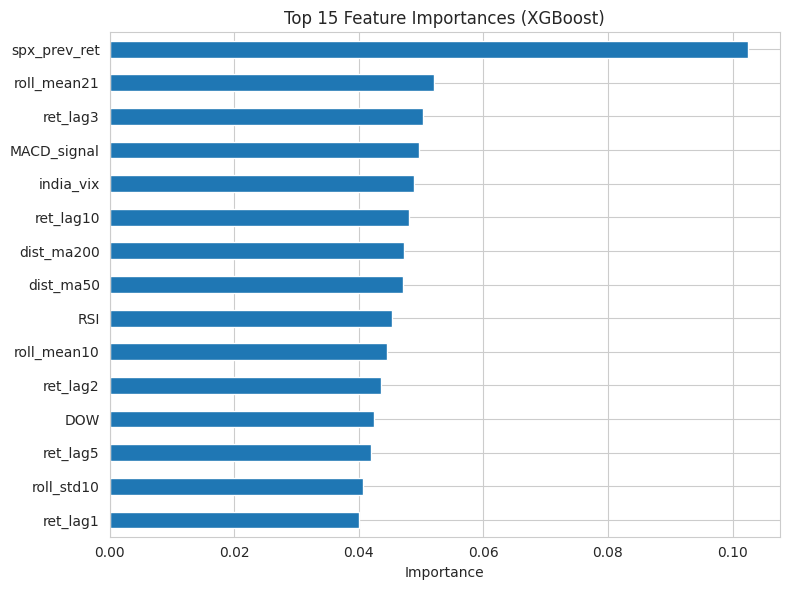

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test.index, test["strat_cum"], label="ML Strategy (net of costs)")
ax.plot(test.index, test["bh_cum"], label="Buy & Hold")
ax.set_title("Strategy vs Buy-and-Hold: Cumulative Returns (Out-of-Sample)")
ax.legend(); save_fig("08_strategy_vs_buyhold"); plt.show()

# Feature importance
imp = pd.Series(best.feature_importances_, index=features).sort_values()
imp.tail(15).plot(kind="barh", figsize=(8, 6), title="Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance"); plt.tight_layout(); save_fig("09_feature_importance"); plt.show()

## 5. Trying to Fix the Obvious Problems

Two things bug me about the strategy above:

1. It's long or flat only. So on a day it correctly predicts "down", it just sits in cash instead
   of actually making money off it. And in a market that mostly goes up over time, sitting in
   cash on the wrong days costs a lot.
2. The model is trained once (on the first 80% of data) and then just used as-is for the rest.
   It never updates itself even as the market changes.

So below, I'm doing two things differently: retraining the models every ~3 months instead of
once, and turning the prediction into an actual long/short position sized by how confident the
model is (instead of just "in or out"). If it's not very confident either way, it stays flat.

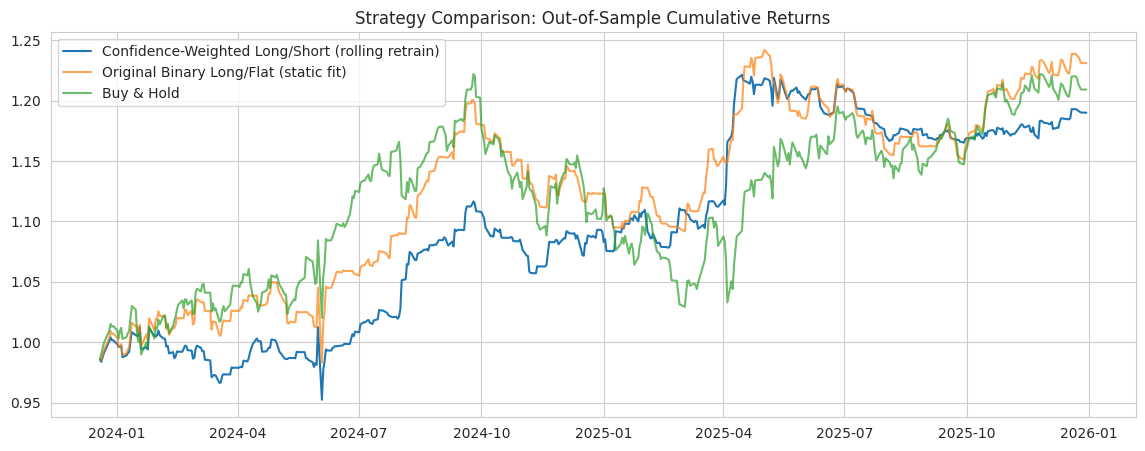

,Conf-Weighted L/S,Binary Long/Flat,Buy & Hold
Sharpe,1.0183,1.0705,0.8022
Sortino,1.2659,1.3131,1.0729
Max Drawdown,-0.0593,-0.0907,-0.1577
Calmar,1.5421,1.2154,0.6356
Win Rate,0.4334,0.4208,NaN
# Trades,275.2901,210.0000,NaN


In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

retrain_every = 63  # ~1 trading quarter
probs = np.full(len(data), np.nan)

for start in range(split, len(data), retrain_every):
    end = min(start + retrain_every, len(data))
    train_slice = slice(0, start)   # expanding window: always train on all history up to `start`

    scaler = StandardScaler().fit(X.iloc[train_slice])
    Xtr, ytr = scaler.transform(X.iloc[train_slice]), y.iloc[train_slice]

    m_lr  = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
    m_rf  = RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42).fit(Xtr, ytr)
    m_xgb = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                          random_state=42, eval_metric="logloss").fit(Xtr, ytr)

    Xte = scaler.transform(X.iloc[start:end])
    ens_proba = (m_lr.predict_proba(Xte)[:, 1]
                 + m_rf.predict_proba(Xte)[:, 1]
                 + m_xgb.predict_proba(Xte)[:, 1]) / 3
    probs[start:end] = ens_proba

test2 = data.iloc[split:].copy()
test2["proba"] = probs[split:]

# Confidence-weighted long/short position: deadband for low-conviction days,
# scaled exposure elsewhere, capped at full (+-1) position
conviction = test2["proba"] - 0.5
DEADBAND = 0.03
SCALE = 6.0
position = np.where(np.abs(conviction) < DEADBAND, 0.0,
                     np.sign(conviction) * np.clip(np.abs(conviction) * SCALE, 0, 1))
test2["position"] = position

test2["next_ret"] = test2["Return"].shift(-1)
turn = pd.Series(position, index=test2.index).diff().abs().fillna(0)
test2["strat_ret"] = test2["position"] * test2["next_ret"] - turn * COST
test2["strat_cum"] = (1 + test2["strat_ret"].fillna(0)).cumprod()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(test2.index, test2["strat_cum"], label="Confidence-Weighted Long/Short (rolling retrain)")
ax.plot(test.index, test["strat_cum"], label="Original Binary Long/Flat (static fit)", alpha=0.7)
ax.plot(test.index, test["bh_cum"], label="Buy & Hold", alpha=0.7)
ax.set_title("Strategy Comparison: Out-of-Sample Cumulative Returns")
ax.legend(); save_fig("10_strategy_comparison"); plt.show()

metrics2 = pd.DataFrame({
    "Conf-Weighted L/S": [sharpe(test2["strat_ret"]), sortino(test2["strat_ret"]),
                          max_dd(test2["strat_cum"]), calmar(test2["strat_ret"], test2["strat_cum"]),
                          win_rate(test2["strat_ret"]), turn.sum()],
    "Binary Long/Flat":  [sharpe(test["strat_ret"]), sortino(test["strat_ret"]),
                          max_dd(test["strat_cum"]), calmar(test["strat_ret"], test["strat_cum"]),
                          win_rate(test["strat_ret"]), trades.sum()],
    "Buy & Hold":        [sharpe(test["next_ret"]), sortino(test["next_ret"]),
                          max_dd(test["bh_cum"]), calmar(test["next_ret"], test["bh_cum"]),
                          np.nan, np.nan],
}, index=["Sharpe", "Sortino", "Max Drawdown", "Calmar", "Win Rate", "# Trades"])

metrics2.round(4)